<a href="https://colab.research.google.com/github/Dimas0824/PCVK/blob/main/Pertemuan10/PCVK_Week10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# D. Tugas Praktikum

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

 fungsi dilasi serta tampilkan hasil dilasi pada citra dengan Structuring Element
Dilasi (SED) berbentuk cross 3 x 3 tanpa menggunakan library morphology dari
openCV, sehingga menghasilkan tampilan seperti di bawah ini:

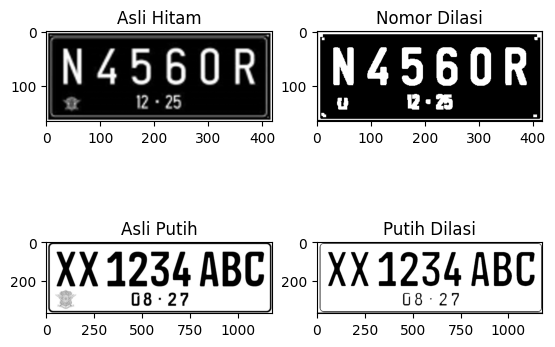

In [37]:
# Fungsi dilasi manual
def dilasi_citra(F, w):
    p, q = F.shape
    imgD = np.zeros((p, q), dtype=np.uint8)
    SED = np.ones((w, w), dtype=np.uint8)
    c = (w - 1) // 2
    for i in range(c, p - c):
        for j in range(c, q - c):
            temp = F[i-c:i+c+1, j-c:j+c+1]
            imgD[i, j] = np.max(temp * SED)
    return imgD

# Plat Nomor
img_nomor = cv2.imread('/content/drive/MyDrive/PCVK/Images/Images/PlatNomor.png', 0)
_, th_nomor = cv2.threshold(img_nomor, 125, 255, cv2.THRESH_BINARY)
imgD_nomor = dilasi_citra(th_nomor, 5)

# Plat Putih
img_putih = cv2.imread('/content/drive/MyDrive/PCVK/Images/Images/PlatPutih.png', 0)
_, th_putih = cv2.threshold(img_putih, 125, 255, cv2.THRESH_BINARY)
imgD_putih = dilasi_citra(th_putih, 5)

# Plot
plt.subplot(221), plt.imshow(img_nomor, cmap='gray'), plt.title('Asli Hitam')
plt.subplot(222), plt.imshow(imgD_nomor, cmap='gray'), plt.title('Nomor Dilasi')
plt.subplot(223), plt.imshow(img_putih, cmap='gray'), plt.title('Asli Putih')
plt.subplot(224), plt.imshow(imgD_putih, cmap='gray'), plt.title('Putih Dilasi')
plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

program implementasi operasi dilasi Structuring Element Dilasi (SED)
berbentuk cross 3 x 3 dengan menggunakan library morphology dari openCV,
sehingga menghasilkan tampilan seperti di bawah ini:  

Kernel yang digunakan:
 [[1 1 1]
 [1 1 1]
 [1 1 1]]


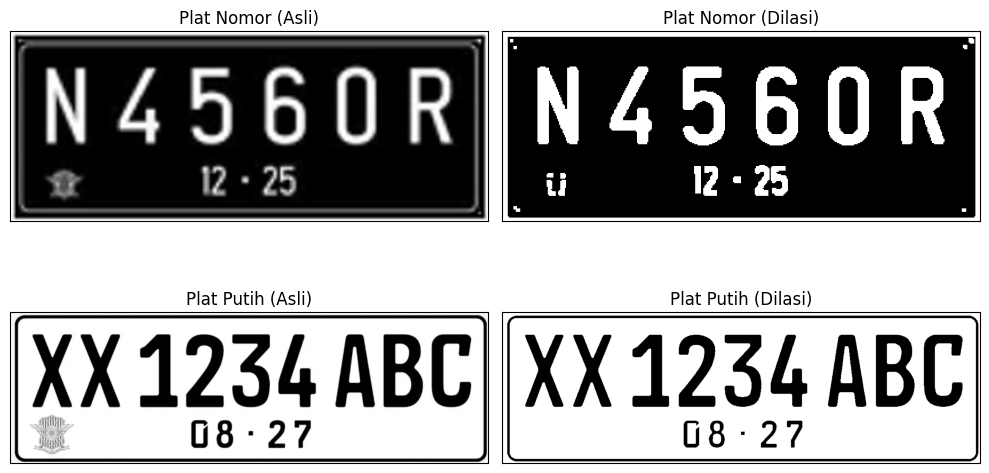

In [38]:
# === Citra input ===
img_nomor = cv2.imread('/content/drive/MyDrive/PCVK/Images/Images/PlatNomor.png', 0)
img_putih = cv2.imread('/content/drive/MyDrive/PCVK/Images/Images/PlatPutih.png', 0)

# === Thresholding ===
ret1, thresh_nomor = cv2.threshold(img_nomor, 127, 255, cv2.THRESH_BINARY)
ret2, thresh_putih = cv2.threshold(img_putih, 127, 255, cv2.THRESH_BINARY)

# === Kernel & Dilation ===
kernel = np.ones((3,3), np.uint8)
dilasi_nomor = cv2.dilate(thresh_nomor, kernel, iterations=1)
dilasi_putih = cv2.dilate(thresh_putih, kernel, iterations=1)

print("Kernel yang digunakan:\n", kernel)

# === Visualisasi ===
plt.figure(figsize=(10,6))

plt.subplot(221), plt.imshow(img_nomor, cmap='gray'), plt.title('Plat Nomor (Asli)')
plt.xticks([]), plt.yticks([])

plt.subplot(222), plt.imshow(dilasi_nomor, cmap='gray'), plt.title('Plat Nomor (Dilasi)')
plt.xticks([]), plt.yticks([])

plt.subplot(223), plt.imshow(img_putih, cmap='gray'), plt.title('Plat Putih (Asli)')
plt.xticks([]), plt.yticks([])

plt.subplot(224), plt.imshow(dilasi_putih, cmap='gray'), plt.title('Plat Putih (Dilasi)')
plt.xticks([]), plt.yticks([])

plt.tight_layout()
plt.show()

 fungsi erosi serta tampilkan hasil erosi pada citra dengan Structuring Element
Erosi (SE) berbentuk square 5 x 5 tanpa menggunakan library morphology dari
openCV, sehingga menghasilkan tampilan seperti di bawah ini:

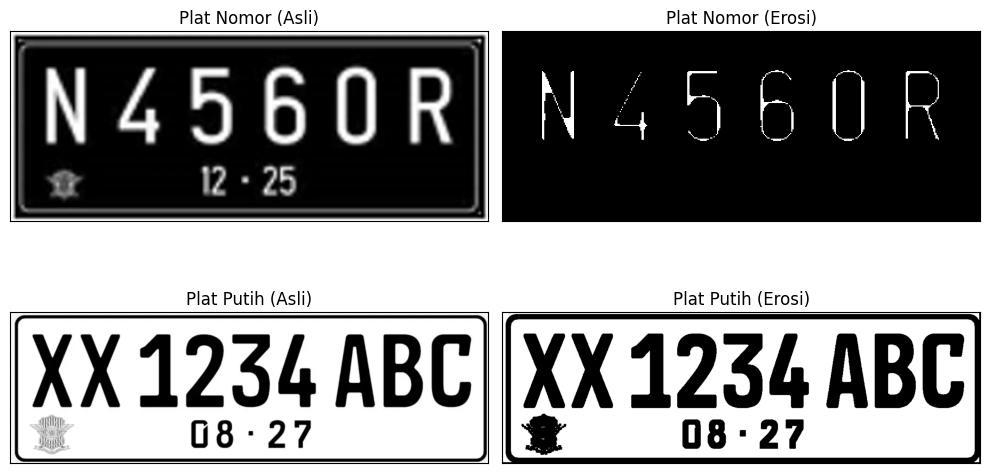

In [39]:
# Fungsi erosi manual
def erosi_citra(F, k):
    m, n = F.shape
    SE = np.ones((k, k), dtype=np.uint8)   # Elemen struktur
    c = (k - 1) // 2
    imgE = np.zeros((m, n), dtype=np.uint8)

    for i in range(c, m - c):
        for j in range(c, n - c):
            temp = F[i-c:i+c+1, j-c:j+c+1]
            product = temp * SE
            imgE[i, j] = np.min(product)

    return imgE

# Baca citra plat nomor dan plat putih
img_nomor = cv2.imread('/content/drive/MyDrive/PCVK/Images/Images/PlatNomor.png', 0)
img_putih = cv2.imread('/content/drive/MyDrive/PCVK/Images/Images/PlatPutih.png', 0)

# Threshold biner
_, thresh_nomor = cv2.threshold(img_nomor, 175, 255, cv2.THRESH_BINARY)
_, thresh_putih = cv2.threshold(img_putih, 175, 255, cv2.THRESH_BINARY)

# Ukuran kernel
k = 5

# Erosi manual
erosi_nomor = erosi_citra(thresh_nomor, k)
erosi_putih = erosi_citra(thresh_putih, k)

# Tampilkan hasil
plt.figure(figsize=(10,6))

plt.subplot(221), plt.imshow(img_nomor, cmap='gray'), plt.title('Plat Nomor (Asli)')
plt.xticks([]), plt.yticks([])

plt.subplot(222), plt.imshow(erosi_nomor, cmap='gray'), plt.title('Plat Nomor (Erosi)')
plt.xticks([]), plt.yticks([])

plt.subplot(223), plt.imshow(img_putih, cmap='gray'), plt.title('Plat Putih (Asli)')
plt.xticks([]), plt.yticks([])

plt.subplot(224), plt.imshow(erosi_putih, cmap='gray'), plt.title('Plat Putih (Erosi)')
plt.xticks([]), plt.yticks([])

plt.tight_layout()
plt.show()

program implementasi operasi dilasi Structuring Element Erosi (SE) berbentuk
square 5 x 5 dengan menggunakan library morphology dari openCV, sehingga
menghasilkan tampilan seperti di bawah ini:

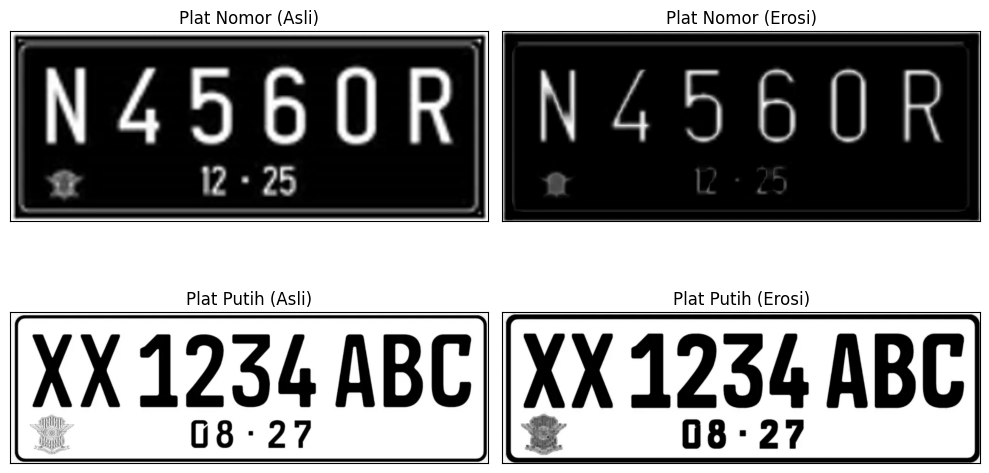

In [40]:
# Baca citra plat nomor dan plat putih
img_nomor = cv2.imread('/content/drive/MyDrive/PCVK/Images/Images/PlatNomor.png', 0)
img_putih = cv2.imread('/content/drive/MyDrive/PCVK/Images/Images/PlatPutih.png', 0)

# Kernel untuk erosi
kernel = np.ones((5,5), np.uint8)

# Proses erosi dengan library OpenCV
erosion_nomor = cv2.erode(img_nomor, kernel, iterations=1)
erosion_putih = cv2.erode(img_putih, kernel, iterations=1)

# Tampilkan hasil
plt.figure(figsize=(10,6))

plt.subplot(221), plt.imshow(img_nomor, cmap='gray'), plt.title('Plat Nomor (Asli)')
plt.xticks([]), plt.yticks([])

plt.subplot(222), plt.imshow(erosion_nomor, cmap='gray'), plt.title('Plat Nomor (Erosi)')
plt.xticks([]), plt.yticks([])

plt.subplot(223), plt.imshow(img_putih, cmap='gray'), plt.title('Plat Putih (Asli)')
plt.xticks([]), plt.yticks([])

plt.subplot(224), plt.imshow(erosion_putih, cmap='gray'), plt.title('Plat Putih (Erosi)')
plt.xticks([]), plt.yticks([])

plt.tight_layout()
plt.show()

program implementasi operasi opening dengan Structuring Element
berbentuk square 3 x 3 tanpa dan dengan menggunakan library morphology dari
openCV, sehingga menghasilkan tampilan seperti di bawah ini:

**Operasi Opening Menggunakan tanpa Library Morphology**

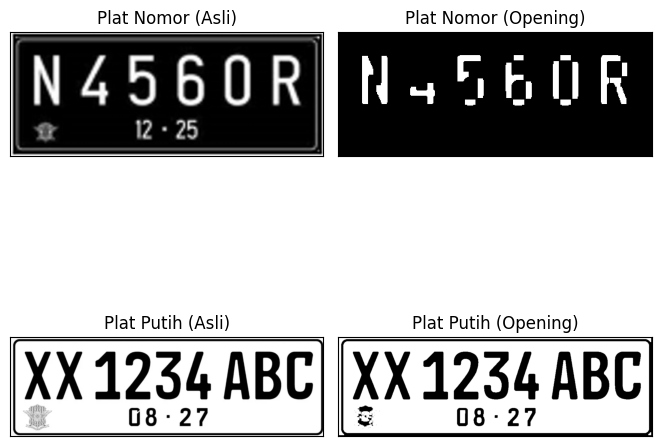

In [41]:
# Fungsi erosi manual
def erosi_citra(F, k):
    m, n = F.shape
    SE = np.ones((k, k), dtype=np.uint8)
    c = (k - 1) // 2
    imgE = np.zeros((m, n), dtype=np.uint8)
    for i in range(c, m - c):
        for j in range(c, n - c):
            temp = F[i-c:i+c+1, j-c:j+c+1]
            product = temp * SE
            imgE[i, j] = np.min(product)
    return imgE

# Fungsi dilasi manual
def dilasi_citra(F, k):
    m, n = F.shape
    SE = np.ones((k, k), dtype=np.uint8)
    c = (k - 1) // 2
    imgD = np.zeros((m, n), dtype=np.uint8)
    for i in range(c, m - c):
        for j in range(c, n - c):
            temp = F[i-c:i+c+1, j-c:j+c+1]
            product = temp * SE
            imgD[i, j] = np.max(product)
    return imgD

# Baca citra plat nomor dan plat putih
img_nomor = cv2.imread('/content/drive/MyDrive/PCVK/Images/Images/PlatNomor.png', 0)
img_putih = cv2.imread('/content/drive/MyDrive/PCVK/Images/Images/PlatPutih.png', 0)

# Threshold biner
_, thresh_nomor = cv2.threshold(img_nomor, 127, 255, cv2.THRESH_BINARY)
_, thresh_putih = cv2.threshold(img_putih, 127, 255, cv2.THRESH_BINARY)

# Ukuran kernel
k = 7

# Proses Opening (Erosi lalu Dilasi)
opening_nomor = dilasi_citra(erosi_citra(thresh_nomor, k), k)
opening_putih = dilasi_citra(erosi_citra(thresh_putih, k), k)

# Tampilkan hasil
plt.figure(figsize=(10,6))

plt.subplot(231), plt.imshow(img_nomor, cmap='gray'), plt.title('Plat Nomor (Asli)')
plt.xticks([]), plt.yticks([])

plt.subplot(232), plt.imshow(opening_nomor, cmap='gray'), plt.title('Plat Nomor (Opening)')
plt.xticks([]), plt.yticks([])

plt.subplot(234), plt.imshow(img_putih, cmap='gray'), plt.title('Plat Putih (Asli)')
plt.xticks([]), plt.yticks([])

plt.subplot(235), plt.imshow(opening_putih, cmap='gray'), plt.title('Plat Putih (Opening)')
plt.xticks([]), plt.yticks([])

plt.tight_layout()
plt.show()

**Operasi Opening Menggunakan Library Morphology**

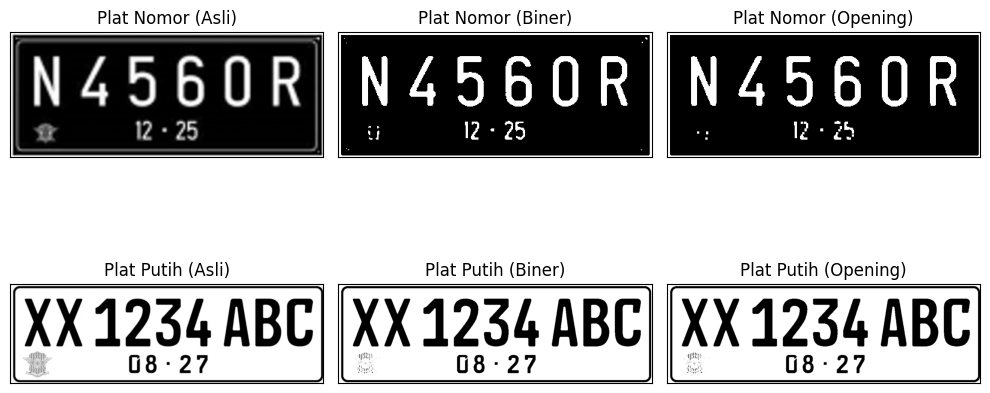

In [43]:
# Baca citra plat nomor dan plat putih (grayscale)
img_nomor = cv2.imread('/content/drive/MyDrive/PCVK/Images/Images/PlatNomor.png', 0)
img_putih = cv2.imread('/content/drive/MyDrive/PCVK/Images/Images/PlatPutih.png', 0)

# Threshold biner
_, thresh_nomor = cv2.threshold(img_nomor, 127, 255, cv2.THRESH_BINARY)
_, thresh_putih = cv2.threshold(img_putih, 127, 255, cv2.THRESH_BINARY)

# Kernel untuk morfologi
kernel = np.ones((3,3), np.uint8)

# Proses Opening (Erosi lalu Dilasi) dengan library
open_nomor = cv2.morphologyEx(thresh_nomor, cv2.MORPH_OPEN, kernel)
open_putih = cv2.morphologyEx(thresh_putih, cv2.MORPH_OPEN, kernel)

# Tampilkan hasil
plt.figure(figsize=(10,6))

plt.subplot(231), plt.imshow(img_nomor, cmap='gray'), plt.title('Plat Nomor (Asli)')
plt.xticks([]), plt.yticks([])

plt.subplot(232), plt.imshow(thresh_nomor, cmap='gray'), plt.title('Plat Nomor (Biner)')
plt.xticks([]), plt.yticks([])

plt.subplot(233), plt.imshow(open_nomor, cmap='gray'), plt.title('Plat Nomor (Opening)')
plt.xticks([]), plt.yticks([])

plt.subplot(234), plt.imshow(img_putih, cmap='gray'), plt.title('Plat Putih (Asli)')
plt.xticks([]), plt.yticks([])

plt.subplot(235), plt.imshow(thresh_putih, cmap='gray'), plt.title('Plat Putih (Biner)')
plt.xticks([]), plt.yticks([])

plt.subplot(236), plt.imshow(open_putih, cmap='gray'), plt.title('Plat Putih (Opening)')
plt.xticks([]), plt.yticks([])

plt.tight_layout()
plt.show()

 program implementasi operasi closing dengan Structuring Element berbentuk
square 3 x 3 tanpa dan dengan menggunakan library morphology dari openCV,
sehingga menghasilkan tampilan seperti di bawah ini:  

operasi closing tanpa library morphology

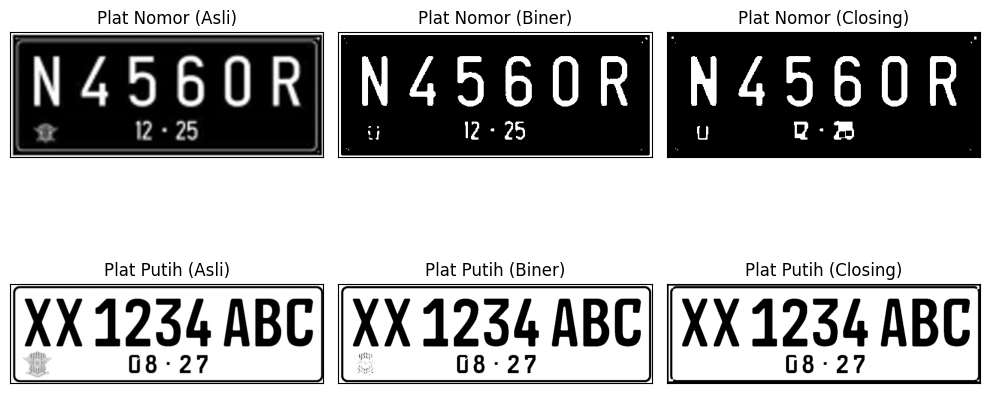

In [44]:
# Fungsi erosi manual
def erosi_citra(F, k):
    m, n = F.shape
    SE = np.ones((k, k), dtype=np.uint8)
    c = (k - 1) // 2
    imgE = np.zeros((m, n), dtype=np.uint8)
    for i in range(c, m - c):
        for j in range(c, n - c):
            temp = F[i-c:i+c+1, j-c:j+c+1]
            product = temp * SE
            imgE[i, j] = np.min(product)
    return imgE

# Fungsi dilasi manual
def dilasi_citra(F, k):
    m, n = F.shape
    SE = np.ones((k, k), dtype=np.uint8)
    c = (k - 1) // 2
    imgD = np.zeros((m, n), dtype=np.uint8)
    for i in range(c, m - c):
        for j in range(c, n - c):
            temp = F[i-c:i+c+1, j-c:j+c+1]
            product = temp * SE
            imgD[i, j] = np.max(product)
    return imgD

# Baca citra plat nomor dan plat putih (grayscale)
img_nomor = cv2.imread('/content/drive/MyDrive/PCVK/Images/Images/PlatNomor.png', 0)
img_putih = cv2.imread('/content/drive/MyDrive/PCVK/Images/Images/PlatPutih.png', 0)

# Threshold biner
_, thresh_nomor = cv2.threshold(img_nomor, 127, 255, cv2.THRESH_BINARY)
_, thresh_putih = cv2.threshold(img_putih, 127, 255, cv2.THRESH_BINARY)

# Ukuran kernel
k = 7

# Proses Closing (Dilasi lalu Erosi)
closing_nomor = erosi_citra(dilasi_citra(thresh_nomor, k), k)
closing_putih = erosi_citra(dilasi_citra(thresh_putih, k), k)

# Tampilkan hasil
plt.figure(figsize=(10,6))

plt.subplot(231), plt.imshow(img_nomor, cmap='gray'), plt.title('Plat Nomor (Asli)')
plt.xticks([]), plt.yticks([])

plt.subplot(232), plt.imshow(thresh_nomor, cmap='gray'), plt.title('Plat Nomor (Biner)')
plt.xticks([]), plt.yticks([])

plt.subplot(233), plt.imshow(closing_nomor, cmap='gray'), plt.title('Plat Nomor (Closing)')
plt.xticks([]), plt.yticks([])

plt.subplot(234), plt.imshow(img_putih, cmap='gray'), plt.title('Plat Putih (Asli)')
plt.xticks([]), plt.yticks([])

plt.subplot(235), plt.imshow(thresh_putih, cmap='gray'), plt.title('Plat Putih (Biner)')
plt.xticks([]), plt.yticks([])

plt.subplot(236), plt.imshow(closing_putih, cmap='gray'), plt.title('Plat Putih (Closing)')
plt.xticks([]), plt.yticks([])

plt.tight_layout()
plt.show()

operasi closing dengan library morphology

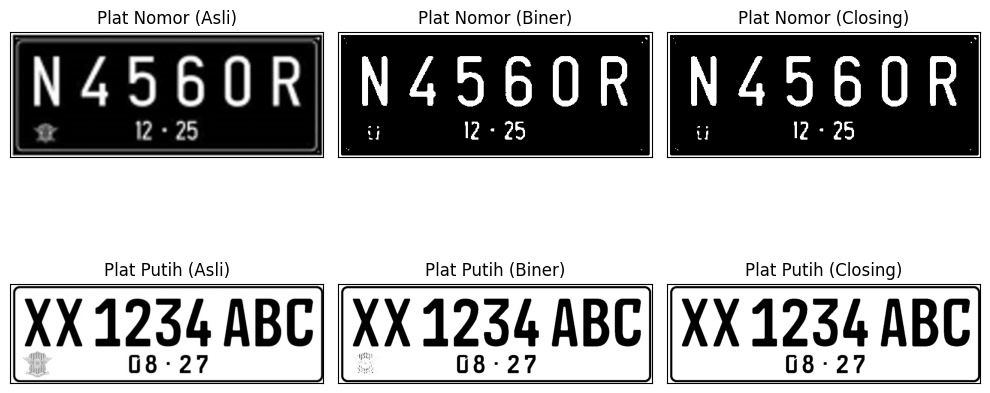

In [47]:
# Baca citra plat nomor dan plat putih (grayscale)
img_nomor = cv2.imread('/content/drive/MyDrive/PCVK/Images/Images/PlatNomor.png', 0)
img_putih = cv2.imread('/content/drive/MyDrive/PCVK/Images/Images/PlatPutih.png', 0)

# Threshold biner
_, thresh_nomor = cv2.threshold(img_nomor, 127, 255, cv2.THRESH_BINARY)
_, thresh_putih = cv2.threshold(img_putih, 127, 255, cv2.THRESH_BINARY)

# Kernel untuk morfologi
kernel = np.ones((3,3), np.uint8)

# Proses Closing (Dilasi lalu Erosi) dengan library
close_nomor = cv2.morphologyEx(thresh_nomor, cv2.MORPH_CLOSE, kernel)
close_putih = cv2.morphologyEx(thresh_putih, cv2.MORPH_CLOSE, kernel)

# Tampilkan hasil
plt.figure(figsize=(10,6))

plt.subplot(231), plt.imshow(img_nomor, cmap='gray'), plt.title('Plat Nomor (Asli)')
plt.xticks([]), plt.yticks([])

plt.subplot(232), plt.imshow(thresh_nomor, cmap='gray'), plt.title('Plat Nomor (Biner)')
plt.xticks([]), plt.yticks([])

plt.subplot(233), plt.imshow(close_nomor, cmap='gray'), plt.title('Plat Nomor (Closing)')
plt.xticks([]), plt.yticks([])

plt.subplot(234), plt.imshow(img_putih, cmap='gray'), plt.title('Plat Putih (Asli)')
plt.xticks([]), plt.yticks([])

plt.subplot(235), plt.imshow(thresh_putih, cmap='gray'), plt.title('Plat Putih (Biner)')
plt.xticks([]), plt.yticks([])

plt.subplot(236), plt.imshow(close_putih, cmap='gray'), plt.title('Plat Putih (Closing)')
plt.xticks([]), plt.yticks([])

plt.tight_layout()
plt.show()

 program implementasi operasi dilasi dengan Structuring Element berbentuk
Cross 3 x 3  dan 5 x 5, sehingga menghasilkan tampilan seperti di bawah ini:

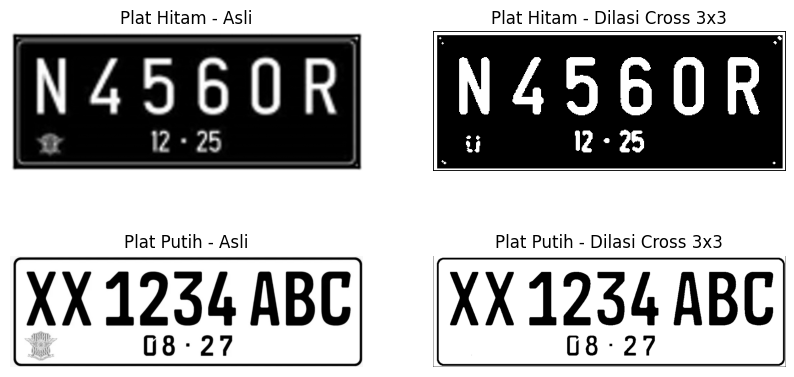

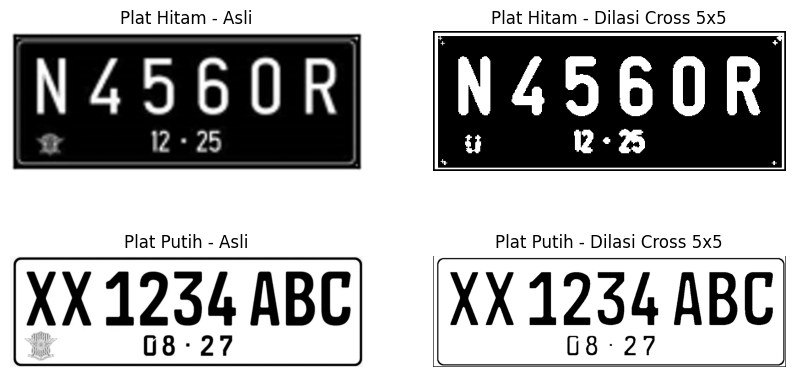

In [48]:
def dilasi_citra(F, w, SED):
    p, q = F.shape
    imgD = np.zeros((p, q), dtype=np.uint8)
    c = (w - 1) // 2
    for i in range(c, p - c):
        for j in range(c, q - c):
            temp = F[i-c:i+c+1, j-c:j+c+1]
            imgD[i, j] = np.max(temp * SED)
    return imgD

# Input
img_nomor = cv2.imread('/content/drive/MyDrive/PCVK/Images/Images/PlatNomor.png', 0)
_, thresh_nomor = cv2.threshold(img_nomor, 127, 255, cv2.THRESH_BINARY)

img_putih = cv2.imread('/content/drive/MyDrive/PCVK/Images/Images/PlatPutih.png', 0)
_, thresh_putih = cv2.threshold(img_putih, 127, 255, cv2.THRESH_BINARY)

# Cross 3x3
SED3 = np.array([[0,1,0],
                 [1,1,1],
                 [0,1,0]], dtype=np.uint8)

imgD_nomor_3 = dilasi_citra(thresh_nomor, 3, SED3)
imgD_putih_3 = dilasi_citra(thresh_putih, 3, SED3)

plt.figure(figsize=(10,5))
plt.subplot(221), plt.imshow(img_nomor, cmap='gray'), plt.title('Plat Hitam - Asli'), plt.axis('off')
plt.subplot(222), plt.imshow(imgD_nomor_3, cmap='gray'), plt.title('Plat Hitam - Dilasi Cross 3x3'), plt.axis('off')
plt.subplot(223), plt.imshow(img_putih, cmap='gray'), plt.title('Plat Putih - Asli'), plt.axis('off')
plt.subplot(224), plt.imshow(imgD_putih_3, cmap='gray'), plt.title('Plat Putih - Dilasi Cross 3x3'), plt.axis('off')
plt.show()

# Cross 5x5
SED5 = np.array([[0,0,1,0,0],
                 [0,0,1,0,0],
                 [1,1,1,1,1],
                 [0,0,1,0,0],
                 [0,0,1,0,0]], dtype=np.uint8)

imgD_nomor_5 = dilasi_citra(thresh_nomor, 5, SED5)
imgD_putih_5 = dilasi_citra(thresh_putih, 5, SED5)

plt.figure(figsize=(10,5))
plt.subplot(221), plt.imshow(img_nomor, cmap='gray'), plt.title('Plat Hitam - Asli'), plt.axis('off')
plt.subplot(222), plt.imshow(imgD_nomor_5, cmap='gray'), plt.title('Plat Hitam - Dilasi Cross 5x5'), plt.axis('off')
plt.subplot(223), plt.imshow(img_putih, cmap='gray'), plt.title('Plat Putih - Asli'), plt.axis('off')
plt.subplot(224), plt.imshow(imgD_putih_5, cmap='gray'), plt.title('Plat Putih - Dilasi Cross 5x5'), plt.axis('off')
plt.show()


 program implementasi operasi dilasi dengan Structuring Element berbentuk
Circular 3 x 3  dan 5 x 5, sehingga menghasilkan tampilan seperti di bawah ini:  

SED = Circle 3


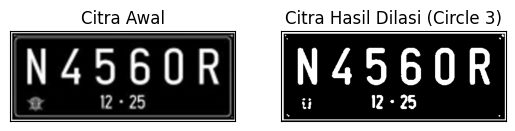

SED = Circle 3 (Plat Putih)


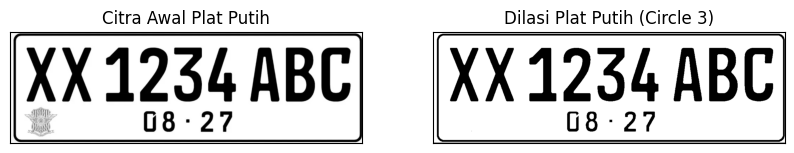

SED = Circle 5


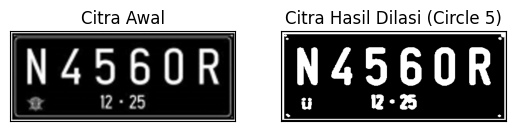

SED = Circle 5 (Plat Putih)


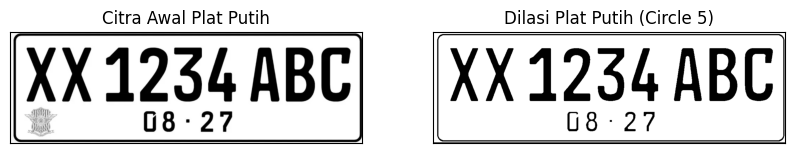

In [2]:
# Dilasi Circular SED

import cv2
import numpy as np
import matplotlib.pyplot as plt

def dilasi_citra(F, w):
    # size image
    p, q = F.shape

    imgD = np.zeros((p, q), dtype=np.uint8)

    # Generate structure element dilasi (SED)
    SED = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (w, w))
    constant1 = (w - 1) // 2

    # Proses Dilasi
    for i in range(constant1, p - constant1):
        for j in range(constant1, q - constant1):
            temp = F[i-constant1:i+constant1+1, j-constant1:j+constant1+1]
            product = temp * SED
            imgD[i, j] = np.max(product)

    return imgD


# --- Circle 3 ---
print('SED = Circle 3')
img_d = cv2.imread('/content/drive/MyDrive/PCVK/Images/Images/PlatNomor.png', 0)
ret, thresh = cv2.threshold(img_d, 127, 225, cv2.THRESH_BINARY)
w = 3
imgD = dilasi_citra(thresh, w)

plt.subplot(121), plt.imshow(img_d, cmap='gray')
plt.title('Citra Awal'), plt.xticks([]), plt.yticks([])

plt.subplot(122), plt.imshow(imgD, cmap='gray')
plt.title('Citra Hasil Dilasi (Circle 3)'), plt.xticks([]), plt.yticks([])

plt.show()

# --- Circle 3 (Plat Putih) ---
print('SED = Circle 3 (Plat Putih)')
img_d2 = cv2.imread('/content/drive/MyDrive/PCVK/Images/Images/PlatPutih.png', 0)
ret2, thresh2 = cv2.threshold(img_d2, 127, 225, cv2.THRESH_BINARY)
w = 3
imgD2 = dilasi_citra(thresh2, w)

plt.figure(figsize=(10, 5))

plt.subplot(121), plt.imshow(img_d2, cmap='gray')
plt.title('Citra Awal Plat Putih'), plt.xticks([]), plt.yticks([])

plt.subplot(122), plt.imshow(imgD2, cmap='gray')
plt.title('Dilasi Plat Putih (Circle 3)'), plt.xticks([]), plt.yticks([])

plt.show()

# --- Circle 5 ---
print('SED = Circle 5')
img_d = cv2.imread('/content/drive/MyDrive/PCVK/Images/Images/PlatNomor.png', 0)
ret, thresh = cv2.threshold(img_d, 127, 225, cv2.THRESH_BINARY)
w = 5
imgD = dilasi_citra(thresh, w)

plt.subplot(121), plt.imshow(img_d, cmap='gray')
plt.title('Citra Awal'), plt.xticks([]), plt.yticks([])

plt.subplot(122), plt.imshow(imgD, cmap='gray')
plt.title('Citra Hasil Dilasi (Circle 5)'), plt.xticks([]), plt.yticks([])

plt.show()

# --- Circle 5 (Plat Putih) ---
print('SED = Circle 5 (Plat Putih)')
img_d2 = cv2.imread('/content/drive/MyDrive/PCVK/Images/Images/PlatPutih.png', 0)
ret2, thresh2 = cv2.threshold(img_d2, 127, 225, cv2.THRESH_BINARY)
w = 5
imgD2 = dilasi_citra(thresh2, w)

plt.figure(figsize=(10, 5))

plt.subplot(121), plt.imshow(img_d2, cmap='gray')
plt.title('Citra Awal Plat Putih'), plt.xticks([]), plt.yticks([])

plt.subplot(122), plt.imshow(imgD2, cmap='gray')
plt.title('Dilasi Plat Putih (Circle 5)'), plt.xticks([]), plt.yticks([])

plt.show()

program implementasi operasi erosi dengan Structuring Element berbentuk
Rectangle 3 x 5  dan 5 x 7, sehingga menghasilkan tampilan seperti di bawah ini:  

SE = Rectangle 3x5


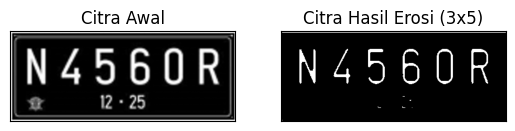

SE = Rectangle 3x5 (Plat Putih)


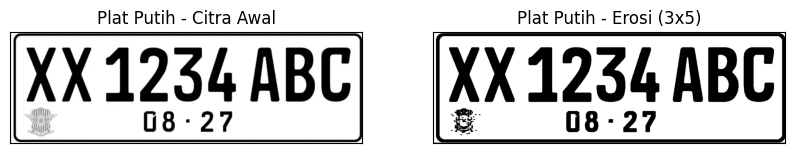

SE = Rectangle 5x7


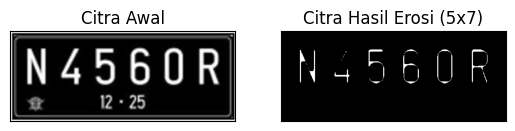

SE = Rectangle 5x7 (Plat Putih)


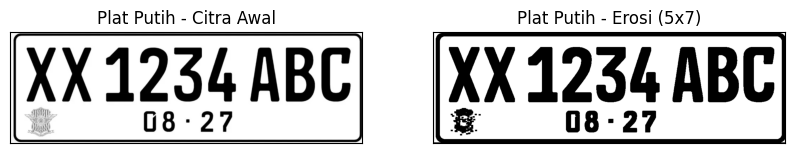

In [3]:
# Erosi Cross SE

import cv2
import numpy as np
import matplotlib.pyplot as plt

def erosi_citra(F, p, l):
    # size image
    m, n = F.shape

    # Generate structure element erosi (SE)
    SE = cv2.getStructuringElement(cv2.MORPH_RECT, (p, l))  # SE persegi panjang
    constant1 = (l - 1) // 2
    constant2 = (p - 1) // 2

    imgE = np.zeros((m, n), dtype=np.uint8)

    # Proses Erosi
    for i in range(constant1, m - constant1):
        for j in range(constant2, n - constant2):
            temp = F[i-constant1:i+constant1+1, j-constant2:j+constant2+1]
            product = temp * SE
            imgE[i, j] = np.min(product)

    return imgE


# --- SE Rectangle 3x5 ---
print('SE = Rectangle 3x5')
img_e = cv2.imread('/content/drive/MyDrive/PCVK/Images/Images/PlatNomor.png', 0)
ret1, thresh1 = cv2.threshold(img_e, 127, 225, cv2.THRESH_BINARY)
p, l = 5, 3
imgE = erosi_citra(thresh1, p, l)

plt.subplot(121), plt.imshow(img_e, cmap='gray')
plt.title('Citra Awal'), plt.xticks([]), plt.yticks([])

plt.subplot(122), plt.imshow(imgE, cmap='gray')
plt.title('Citra Hasil Erosi (3x5)'), plt.xticks([]), plt.yticks([])

plt.show()

# --- SE Rectangle 3x5 (Plat Putih) ---
print('SE = Rectangle 3x5 (Plat Putih)')
img_e2 = cv2.imread('/content/drive/MyDrive/PCVK/Images/Images/PlatPutih.png', 0)
ret2, thresh2 = cv2.threshold(img_e2, 127, 225, cv2.THRESH_BINARY)
p, l = 5, 3
imgE2 = erosi_citra(thresh2, p, l)

plt.figure(figsize=(10, 5))
plt.subplot(121), plt.imshow(img_e2, cmap='gray')
plt.title('Plat Putih - Citra Awal'), plt.xticks([]), plt.yticks([])

plt.subplot(122), plt.imshow(imgE2, cmap='gray')
plt.title('Plat Putih - Erosi (3x5)'), plt.xticks([]), plt.yticks([])

plt.show()

# --- SE Rectangle 5x7 ---
print('SE = Rectangle 5x7')
img_e = cv2.imread('/content/drive/MyDrive/PCVK/Images/Images/PlatNomor.png', 0)
ret1, thresh1 = cv2.threshold(img_e, 127, 225, cv2.THRESH_BINARY)
p, l = 7, 5
imgE = erosi_citra(thresh1, p, l)

plt.subplot(121), plt.imshow(img_e, cmap='gray')
plt.title('Citra Awal'), plt.xticks([]), plt.yticks([])

plt.subplot(122), plt.imshow(imgE, cmap='gray')
plt.title('Citra Hasil Erosi (5x7)'), plt.xticks([]), plt.yticks([])

plt.show()

# --- SE Rectangle 5x7 (Plat Putih) ---
print('SE = Rectangle 5x7 (Plat Putih)')
img_e2 = cv2.imread('/content/drive/MyDrive/PCVK/Images/Images/PlatPutih.png', 0)
ret2, thresh2 = cv2.threshold(img_e2, 127, 225, cv2.THRESH_BINARY)
p, l = 7, 5
imgE2 = erosi_citra(thresh2, p, l)

plt.figure(figsize=(10, 5))
plt.subplot(121), plt.imshow(img_e2, cmap='gray')
plt.title('Plat Putih - Citra Awal'), plt.xticks([]), plt.yticks([])

plt.subplot(122), plt.imshow(imgE2, cmap='gray')
plt.title('Plat Putih - Erosi (5x7)'), plt.xticks([]), plt.yticks([])

plt.show()

program implementasi operasi erosi dengan Structuring Element berbentuk
Line Vertikal 3 dan 5, sehingga menghasilkan tampilan seperti di bawah ini: (Gunakan
gambar j.png)  

SE = Line Vertikal 3


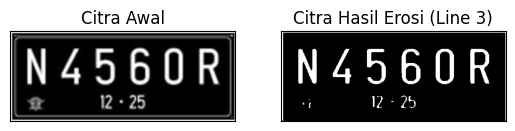

SE = Line Vertikal 3 (Plat Putih)


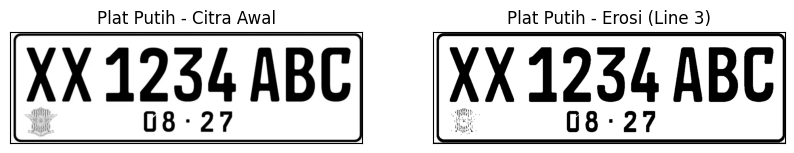

SE = Line Vertikal 5


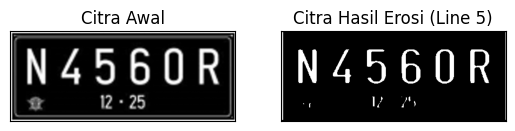

SE = Line Vertikal 5 (Plat Putih)


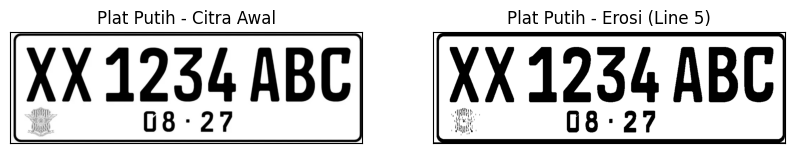

In [5]:
# Erosi Line Vertikal SE

import cv2
import numpy as np
import matplotlib.pyplot as plt

def erosi_citra(F, k):
    # size image
    m, n = F.shape

    # Generate structure element erosi (SE) line vertikal
    SE = cv2.getStructuringElement(cv2.MORPH_RECT, (1, k))
    constant = (k - 1) // 2

    imgE = np.zeros((m, n), dtype=np.uint8)

    # Proses Erosi
    for i in range(constant, m - constant):
        for j in range(constant, n - constant):
            temp = F[i-constant:i+constant+1, j:j+1]  # ambil kolom vertikal
            product = temp * SE
            imgE[i, j] = np.min(product)

    return imgE


# --- SE Line Vertikal 3 ---
print('SE = Line Vertikal 3')
img_e = cv2.imread('/content/drive/MyDrive/PCVK/Images/Images/PlatNomor.png', 0)
ret1, thresh1 = cv2.threshold(img_e, 127, 225, cv2.THRESH_BINARY)
k = 3
imgE = erosi_citra(thresh1, k)

plt.subplot(121), plt.imshow(img_e, cmap='gray')
plt.title('Citra Awal'), plt.xticks([]), plt.yticks([])

plt.subplot(122), plt.imshow(imgE, cmap='gray')
plt.title('Citra Hasil Erosi (Line 3)'), plt.xticks([]), plt.yticks([])

plt.show()

# --- SE Line Vertikal 3 (Plat Putih) ---
print('SE = Line Vertikal 3 (Plat Putih)')
img_e2 = cv2.imread('/content/drive/MyDrive/PCVK/Images/Images/PlatPutih.png', 0)
ret2, thresh2 = cv2.threshold(img_e2, 127, 225, cv2.THRESH_BINARY)
k = 3
imgE2 = erosi_citra(thresh2, k)

plt.figure(figsize=(10, 5))
plt.subplot(121), plt.imshow(img_e2, cmap='gray')
plt.title('Plat Putih - Citra Awal'), plt.xticks([]), plt.yticks([])

plt.subplot(122), plt.imshow(imgE2, cmap='gray')
plt.title('Plat Putih - Erosi (Line 3)'), plt.xticks([]), plt.yticks([])

plt.show()

# --- SE Line Vertikal 5 ---
print('SE = Line Vertikal 5')
img_e = cv2.imread('/content/drive/MyDrive/PCVK/Images/Images/PlatNomor.png', 0)
ret1, thresh1 = cv2.threshold(img_e, 127, 225, cv2.THRESH_BINARY)
k = 5
imgE = erosi_citra(thresh1, k)

plt.subplot(121), plt.imshow(img_e, cmap='gray')
plt.title('Citra Awal'), plt.xticks([]), plt.yticks([])

plt.subplot(122), plt.imshow(imgE, cmap='gray')
plt.title('Citra Hasil Erosi (Line 5)'), plt.xticks([]), plt.yticks([])

plt.show()

# --- SE Line Vertikal 5 (Plat Putih) ---
print('SE = Line Vertikal 5 (Plat Putih)')
img_e2 = cv2.imread('/content/drive/MyDrive/PCVK/Images/Images/PlatPutih.png', 0)
ret2, thresh2 = cv2.threshold(img_e2, 127, 225, cv2.THRESH_BINARY)
k = 5
imgE2 = erosi_citra(thresh2, k)

plt.figure(figsize=(10, 5))
plt.subplot(121), plt.imshow(img_e2, cmap='gray')
plt.title('Plat Putih - Citra Awal'), plt.xticks([]), plt.yticks([])

plt.subplot(122), plt.imshow(imgE2, cmap='gray')
plt.title('Plat Putih - Erosi (Line 5)'), plt.xticks([]), plt.yticks([])

plt.show()

## ANALISIS HASIL PENGOLAHAN CITRA PADA PLAT KENDARAAN DIATAS

Pada hasil pengolahaan citra diatas plat putih memberikan haris yang jauh lebih jelas dan konsisten dapat dibaca pada semua operasi morfologi karena memiliki kontras tinggi, noise rendah, serta distribusi intensitas piksel yang lebuh mudah dipisahkan menggunakan semua metode. Desain pada plat putih terbaru yang dikeluarkan kepolisian juga memang sudah disesuaikan untuk keperluan pembacaan otomatis oleh sistem ETLE, menjadikan plat putih lebih unggul dalam proses pengenalan pola dan karakter.

13 TopHat

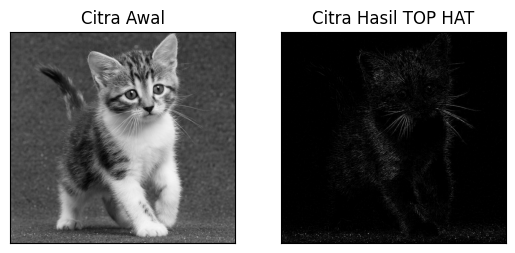

In [26]:
# Getting the kernel to be used in Top-Hat
filterSize = (3, 3)
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, filterSize)

# Reading the image
img = cv2.imread('/content/drive/MyDrive/PCVK/Images/Images/kitten01.jpg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Applying the Top-Hat operation
tophat_img = cv2.morphologyEx(img, cv2.MORPH_TOPHAT, kernel)

# Plotting results
plt.subplot(121), plt.imshow(img, cmap='gray')
plt.title('Citra Awal'), plt.xticks([]), plt.yticks([])

plt.subplot(122), plt.imshow(tophat_img, cmap='gray')
plt.title('Citra Hasil TOP HAT'), plt.xticks([]), plt.yticks([])

plt.show()

14 BLACKHAT

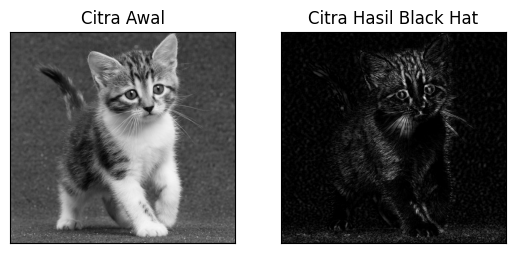

In [30]:
# Kernel awal (tidak dipakai, hanya contoh)
filterSize = (3, 3)
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, filterSize)

# Membaca citra
img = cv2.imread('/content/drive/MyDrive/PCVK/Images/Images/kitten01.jpg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Kernel untuk operasi Black-Hat
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (13, 5))

# Operasi Black-Hat
blackhat = cv2.morphologyEx(img, cv2.MORPH_BLACKHAT, kernel)

# Tampilkan hasil
plt.subplot(121), plt.imshow(img, cmap='gray')
plt.title('Citra Awal'), plt.xticks([]), plt.yticks([])

plt.subplot(122), plt.imshow(blackhat, cmap='gray')
plt.title('Citra Hasil Black Hat'), plt.xticks([]), plt.yticks([])

plt.show()

15. Skeleton

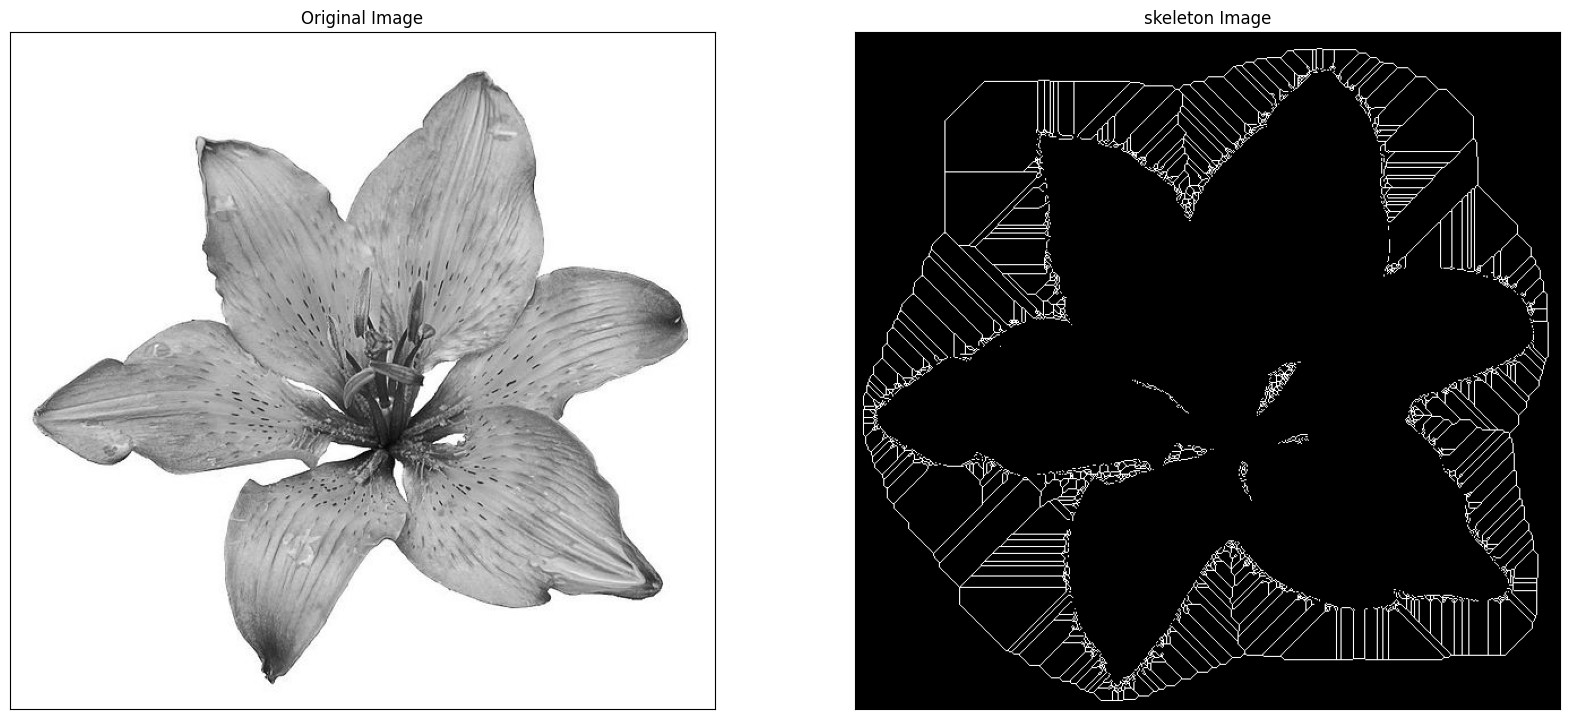

In [31]:
import cv2 as cv
from matplotlib import pyplot as plt
from skimage import filters
from skimage.morphology import skeletonize

# read image
img = cv.imread('/content/drive/MyDrive/PCVK/Images/Images/lily.jpg',0)

binary = img > filters.threshold_triangle(img)

# true false to one
binary_cp = binary.copy()
binary_cp[binary_cp == True] = 1
binary_cp[binary_cp == False] = 0

# skeletonize image
skeleton = skeletonize(binary_cp)

# print images
plt.figure(figsize=(20,20))

plt.subplot(121),plt.imshow(img,cmap = 'gray')
plt.title('Original Image'), plt.xticks([]), plt.yticks([])

plt.subplot(122),plt.imshow(skeleton,cmap = 'gray')
plt.title('skeleton Image'), plt.xticks([]), plt.yticks([])

plt.savefig("binary and bin_skeleton.png")
plt.show()

16. Skeleton Inverse

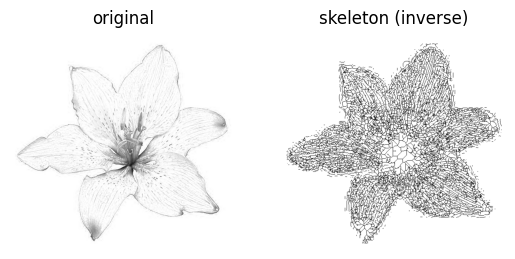

In [32]:
from skimage import io
from matplotlib import pyplot as plt
from skimage import filters
from skimage.morphology import skeletonize

# read image
img = io.imread('/content/drive/MyDrive/PCVK/Images/Images/lily.jpg')[...,0]

# Note: we want the black bits to be True, so use <
binary = img < filters.threshold_triangle(img)

# skeletonize image
skeleton = skeletonize(binary)

# print images
fig, ax = plt.subplots(1, 2)

ax[0].imshow(img, cmap='gray')
ax[0].set_title('original')
ax[0].set_axis_off()

# note the reversed colormap, gray_r
ax[1].imshow(skeleton, cmap='gray_r')
ax[1].set_title('skeleton (inverse)')
ax[1].set_axis_off()
plt.show()

17. Thickening

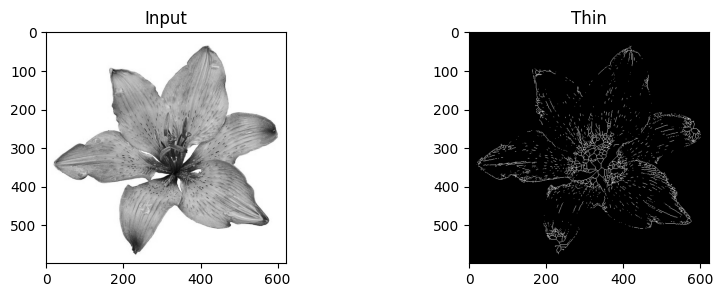

In [33]:
from skimage import img_as_float
from skimage import io, color, morphology
import matplotlib.pyplot as plt

# Membaca citra dan konversi ke grayscale float
image = img_as_float(color.rgb2gray(io.imread('/content/drive/MyDrive/PCVK/Images/Images/lily.jpg')))

# Binerisasi sederhana
image_binary = image < 0.5

# Skeletonize dan thinning
out_skeletonize = morphology.skeletonize(image_binary)
out_thin = morphology.thin(image_binary)

# Plot hasil
f, (ax0, ax1) = plt.subplots(1, 2, figsize=(10, 3))

ax0.imshow(image, cmap='gray')
ax0.set_title('Input')

ax1.imshow(out_thin, cmap='gray')
ax1.set_title('Thin')

plt.savefig('/tmp/char_out.png')
plt.show()